##### Copyright 2018 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Text classification with an RNN

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/text/tutorials/text_classification_rnn"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/text_classification_rnn.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/text/blob/master/docs/tutorials/text_classification_rnn.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/text/docs/tutorials/text_classification_rnn.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This text classification tutorial trains a [recurrent neural network](https://developers.google.com/machine-learning/glossary/#recurrent_neural_network) on the [IMDB large movie review dataset](http://ai.stanford.edu/~amaas/data/sentiment/) for sentiment analysis.

## Setup

In [2]:
import numpy as np

import tensorflow_datasets as tfds
import tensorflow as tf

tfds.disable_progress_bar()

Import `matplotlib` and create a helper function to plot graphs:

In [3]:
import matplotlib.pyplot as plt


def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

## Setup input pipeline


The IMDB large movie review dataset is a *binary classification* dataset—all the reviews have either a *positive* or *negative* sentiment.

Download the dataset using [TFDS](https://www.tensorflow.org/datasets). See the [loading text tutorial](https://www.tensorflow.org/tutorials/load_data/text) for details on how to load this sort of data manually.


In [4]:
dataset, info = tfds.load('imdb_reviews', with_info=True,
                          as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

train_dataset.element_spec

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

Initially this returns a dataset of (text, label pairs):

In [5]:
for example, label in train_dataset.take(1):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0


Next shuffle the data for training and create batches of these `(text, label)` pairs:

In [6]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

In [7]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [8]:
for example, label in train_dataset.take(1):
  print('texts: ', example.numpy()[:3])
  print()
  print('labels: ', label.numpy()[:3])

texts:  [b"I gotta say, Clive Barker's Undying is by far the best horror game to have ever been made. I've played Resident Evil, Silent Hill and the Evil Dead and Castlevania games but none of them have captured the pure glee with which this game tackles its horrific elements. Barker is good at what he does, which is attach the horror to our world, and it shows as his hand is clearly everywhere in this game. Heck, even his voice is in the game as one of the main characters. Full of lush visuals and enough atmosphere to shake a stick at, Undying is the game to beat in my books as the best horror title. I just wish that this had made it to a console system but alas poor PC sales nipped that one in the bud."
 b"I actually didn't start watching the show until it came on FX. I was bored and had nothing to watch and saw that the show's reruns were premiering so i decided to watch it. I was so upset that I had not watched the show when it first aired on t.v. I loved the show so much!Finally a

## Create the text encoder

The raw text loaded by `tfds` needs to be processed before it can be used in a model. The simplest way to process text for training is using the `TextVectorization` layer. This layer has many capabilities, but this tutorial sticks to the default behavior.

Create the layer, and pass the dataset's text to the layer's `.adapt` method:

In [9]:
VOCAB_SIZE = 1000
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label: text))

The `.adapt` method sets the layer's vocabulary. Here are the first 20 tokens. After the padding and unknown tokens they're sorted by frequency:

In [10]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

Once the vocabulary is set, the layer can encode text into indices. The tensors of indices are 0-padded to the longest sequence in the batch (unless you set a fixed `output_sequence_length`):

In [11]:
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[ 10,   1, 130, ...,   0,   0,   0],
       [ 10, 157, 153, ...,   0,   0,   0],
       [  2, 114,   4, ...,   0,   0,   0]])

With the default settings, the process is not completely reversible. There are three main reasons for that:

1. The default value for `preprocessing.TextVectorization`'s `standardize` argument is `"lower_and_strip_punctuation"`.
2. The limited vocabulary size and lack of character-based fallback results in some unknown tokens.

In [12]:
for n in range(3):
  print("Original: ", example[n].numpy())
  print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
  print()

Original:  b"I gotta say, Clive Barker's Undying is by far the best horror game to have ever been made. I've played Resident Evil, Silent Hill and the Evil Dead and Castlevania games but none of them have captured the pure glee with which this game tackles its horrific elements. Barker is good at what he does, which is attach the horror to our world, and it shows as his hand is clearly everywhere in this game. Heck, even his voice is in the game as one of the main characters. Full of lush visuals and enough atmosphere to shake a stick at, Undying is the game to beat in my books as the best horror title. I just wish that this had made it to a console system but alas poor PC sales nipped that one in the bud."
Round-trip:  i [UNK] say [UNK] [UNK] [UNK] is by far the best horror game to have ever been made ive played [UNK] evil [UNK] [UNK] and the evil dead and [UNK] [UNK] but none of them have [UNK] the [UNK] [UNK] with which this game [UNK] its [UNK] elements [UNK] is good at what he doe

## Create the model

![A drawing of the information flow in the model](https://github.com/tensorflow/text/blob/master/docs/tutorials/images/bidirectional.png?raw=1)

Above is a diagram of the model.

1. This model can be build as a `tf.keras.Sequential`.

2. The first layer is the `encoder`, which converts the text to a sequence of token indices.

3. After the encoder is an embedding layer. An embedding layer stores one vector per word. When called, it converts the sequences of word indices to sequences of vectors. These vectors are trainable. After training (on enough data), words with similar meanings often have similar vectors.

  This index-lookup is much more efficient than the equivalent operation of passing a one-hot encoded vector through a `tf.keras.layers.Dense` layer.

4. A recurrent neural network (RNN) processes sequence input by iterating through the elements. RNNs pass the outputs from one timestep to their input on the next timestep.

  The `tf.keras.layers.Bidirectional` wrapper can also be used with an RNN layer. This propagates the input forward and backwards through the RNN layer and then concatenates the final output.

  * The main advantage of a bidirectional RNN is that the signal from the beginning of the input doesn't need to be processed all the way through every timestep to affect the output.  

  * The main disadvantage of a bidirectional RNN is that you can't efficiently stream predictions as words are being added to the end.

5. After the RNN has converted the sequence to a single vector the two `layers.Dense` do some final processing, and convert from this vector representation to a single logit as the classification output.


The code to implement this is below:

In [13]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

Please note that Keras sequential model is used here since all the layers in the model only have single input and produce single output. In case you want to use stateful RNN layer, you might want to build your model with Keras functional API or model subclassing so that you can retrieve and reuse the RNN layer states. Please check [Keras RNN guide](https://www.tensorflow.org/guide/keras/rnn#rnn_state_reuse) for more details.

The embedding layer [uses masking](https://www.tensorflow.org/guide/keras/masking_and_padding) to handle the varying sequence-lengths. All the layers after the `Embedding` support masking:

In [14]:
print([layer.supports_masking for layer in model.layers])

[False, True, True, True, True]


To confirm that this works as expected, evaluate a sentence twice. First, alone so there's no padding to mask:

In [16]:
# predict on a sample text without padding.

sample_text = ('The movie was cool. The animation and the graphics '
               'were out of this world. I would recommend this movie.')
predictions = model.predict(tf.constant([sample_text]))
print(predictions[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[-0.00014137]


Now, evaluate it again in a batch with a longer sentence. The result should be identical:

In [17]:
# predict on a sample text with padding

padding = "the " * 2000
predictions = model.predict(tf.constant([sample_text, padding]))
print(predictions[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
[-0.00014137]


Compile the Keras model to configure the training process:

In [18]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

## Train the model

In [19]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5839 - loss: 0.6360 - val_accuracy: 0.7937 - val_loss: 0.4714
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 80ms/step - accuracy: 0.8181 - loss: 0.3987 - val_accuracy: 0.8323 - val_loss: 0.3591
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.8483 - loss: 0.3429 - val_accuracy: 0.8505 - val_loss: 0.3375
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.8564 - loss: 0.3265 - val_accuracy: 0.8568 - val_loss: 0.3314
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.8603 - loss: 0.3187 - val_accuracy: 0.8521 - val_loss: 0.3315
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8622 - loss: 0.3155 - val_accuracy: 0.8531 - val_loss: 0.3219
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.8675 - loss: 0.3055 - val_accuracy: 0.8214 - val_loss: 0.3719
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.8682 - loss: 0.3029 - 

In [20]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8479 - loss: 0.3205
Test Loss: 0.32053399085998535
Test Accuracy: 0.8478800058364868


(0.0, 0.652800852060318)

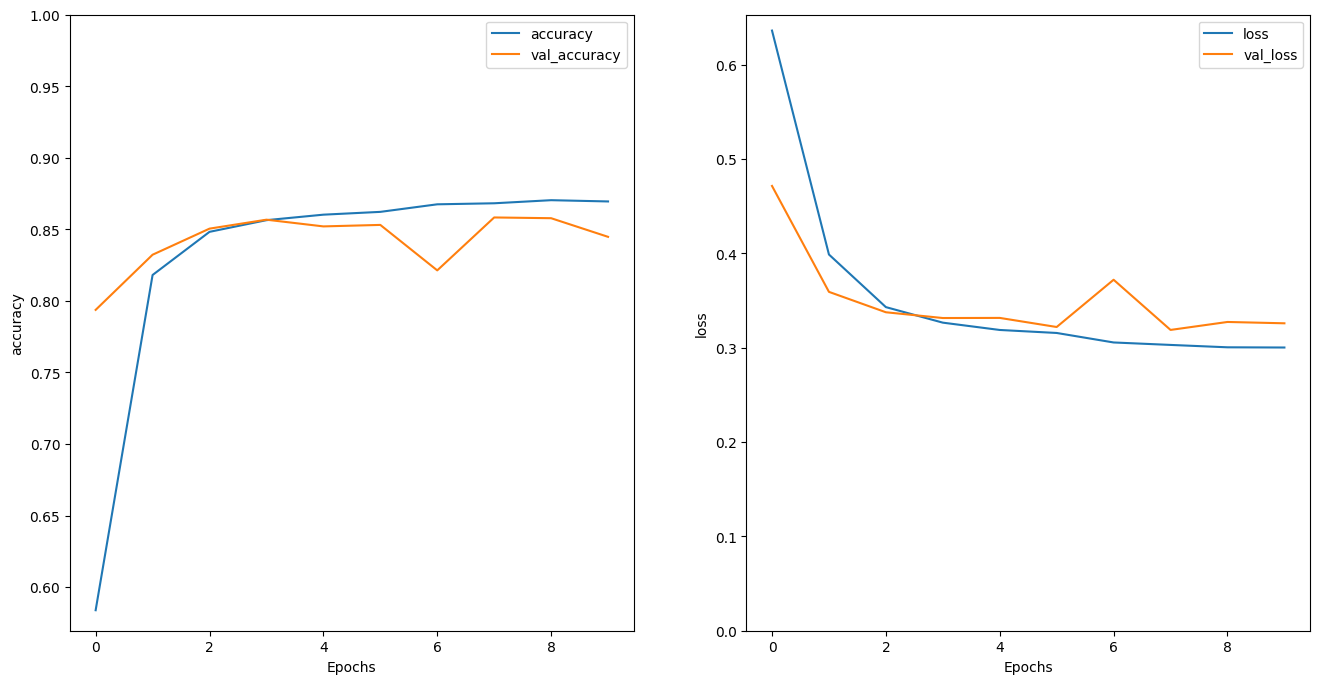

In [21]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

Run a prediction on a new sentence:

If the prediction is >= 0.0, it is positive else it is negative.

In [22]:
sample_text = ('The movie was cool. The animation and the graphics '
               'were out of this world. I would recommend this movie.')
predictions = model.predict(tf.constant([sample_text]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step


## Stack two or more LSTM layers

Keras recurrent layers have two available modes that are controlled by the `return_sequences` constructor argument:

* If `False` it returns only the last output for each input sequence (a 2D tensor of shape (batch_size, output_features)). This is the default, used in the previous model.

* If `True` the full sequences of successive outputs for each timestep is returned (a 3D tensor of shape `(batch_size, timesteps, output_features)`).

Here is what the flow of information looks like with `return_sequences=True`:

![layered_bidirectional](https://github.com/tensorflow/text/blob/master/docs/tutorials/images/layered_bidirectional.png?raw=1)

The interesting thing about using an `RNN` with `return_sequences=True` is that the output still has 3-axes, like the input, so it can be passed to another RNN layer, like this:

In [23]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

In [24]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [25]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 55s 124ms/step - accuracy: 0.5790 - loss: 0.6403 - val_accuracy: 0.7859 - val_loss: 0.4657
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.8156 - loss: 0.4171 - val_accuracy: 0.8036 - val_loss: 0.4036
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 210ms/step - accuracy: 0.8499 - loss: 0.3548 - val_accuracy: 0.8406 - val_loss: 0.3516
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.8609 - loss: 0.3301 - val_accuracy: 0.8641 - val_loss: 0.3313
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.8605 - loss: 0.3207 - val_accuracy: 0.8438 - val_loss: 0.3466
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.8628 - loss: 0.3189 - val_accuracy: 0.8557 - val_loss: 0.3170
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.8653 - loss: 0.3118 - val_accuracy: 0.8510 - val_loss: 0.3198
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.8706 - loss: 0

In [26]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8539 - loss: 0.3136
Test Loss: 0.3135823905467987
Test Accuracy: 0.853879988193512


In [27]:
# predict on a sample text without padding.

sample_text = ('The movie was not good. The animation and the graphics '
               'were terrible. I would not recommend this movie.')
predictions = model.predict(tf.constant([sample_text]))
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
[[-1.4837624]]


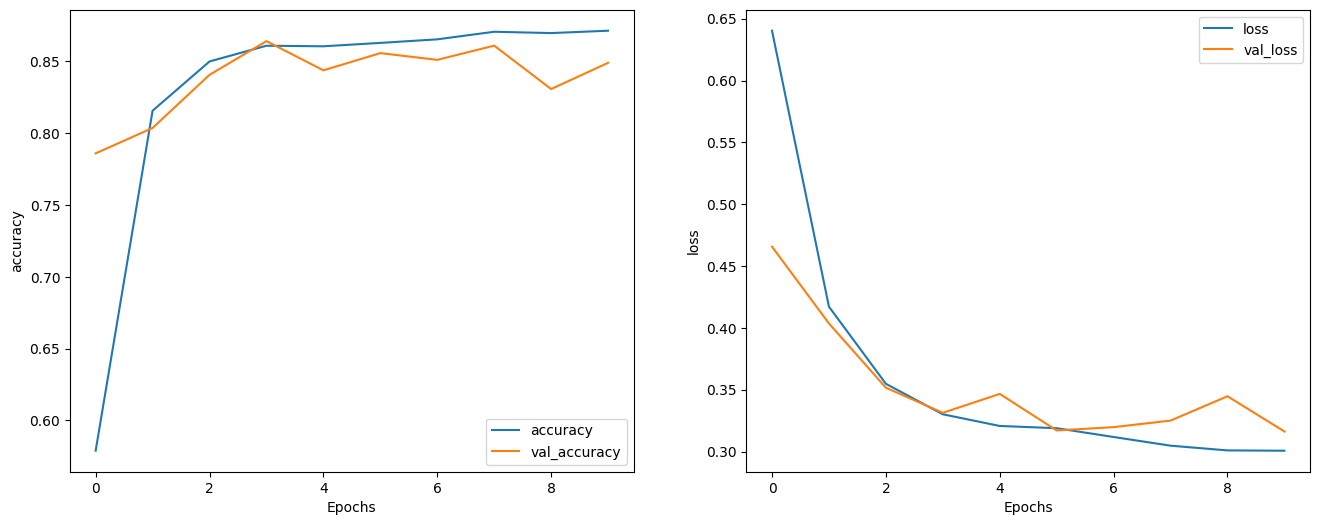

In [28]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')

Check out other existing recurrent layers such as [GRU layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU).

If you're interested in building custom RNNs, see the [Keras RNN Guide](https://www.tensorflow.org/guide/keras/rnn).


TASK 1: DIFFERENT BUFFER & VOCAB SIZE

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.5606 - loss: 0.6434 - val_accuracy: 0.7375 - val_loss: 0.5458
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.7931 - loss: 0.4337 - val_accuracy: 0.8240 - val_loss: 0.3870
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.8451 - loss: 0.3563 - val_accuracy: 0.8344 - val_loss: 0.3544
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.8538 - loss: 0.3362 - val_accuracy: 0.8531 - val_loss: 0.3441
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8625 - loss: 0.3200 - val_accuracy: 0.8573 - val_loss: 0.3360
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.8666 - loss: 0.3108 - val_accuracy: 0.8526 - val_loss: 0.3256
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.8686 - loss: 0.3074 - val_accuracy: 0.8583 - val_loss: 0.3230
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.8677 - loss: 0.3074 - 

(0.0, 0.6605475887656211)

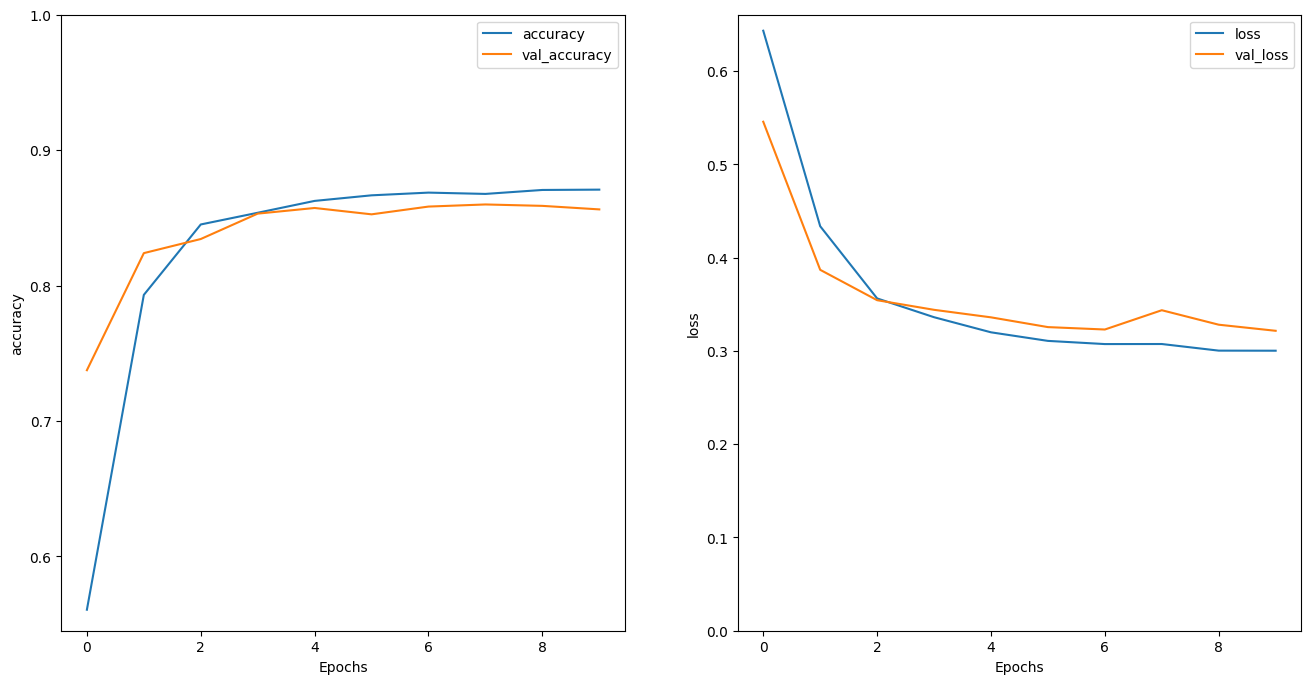

In [30]:
#BASELINE
BUFFER_SIZE = 10000
BATCH_SIZE = 64
VOCAB_SIZE = 1000

train_ds_base = (dataset['train']
                  .shuffle(BUFFER_SIZE)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))
test_ds_base = (dataset['test']
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

encoder_base = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder_base.adapt(train_ds_base.map(lambda text, label: text))

model_base = tf.keras.Sequential([
    encoder_base,
    tf.keras.layers.Embedding(len(encoder_base.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_base.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer=tf.keras.optimizers.Adam(1e-4),
                metrics=['accuracy'])

history_base = model_base.fit(train_ds_base, epochs=10,
                         validation_data=test_ds_base,
                         validation_steps=30)

loss_base, acc_base = model_base.evaluate(test_ds_base)
print(f'Baseline (buffer=10000, vocab=1000) - Test accuracy: {acc_base:.4f}')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history_base, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_base, 'loss')
plt.ylim(0, None)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.5572 - loss: 0.6543 - val_accuracy: 0.7266 - val_loss: 0.5272
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.7932 - loss: 0.4432 - val_accuracy: 0.8255 - val_loss: 0.3854
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.8106 - loss: 0.3941 - val_accuracy: 0.8474 - val_loss: 0.3524
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.8532 - loss: 0.3380 - val_accuracy: 0.8620 - val_loss: 0.3387
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.8614 - loss: 0.3221 - val_accuracy: 0.8594 - val_loss: 0.3347
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.8646 - loss: 0.3182 - val_accuracy: 0.8620 - val_loss: 0.3258
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.8674 - loss: 0.3109 - val_accuracy: 0.8625 - val_loss: 0.3221
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.8702 - loss: 0.3031 - 

(0.0, 0.6719266891479492)

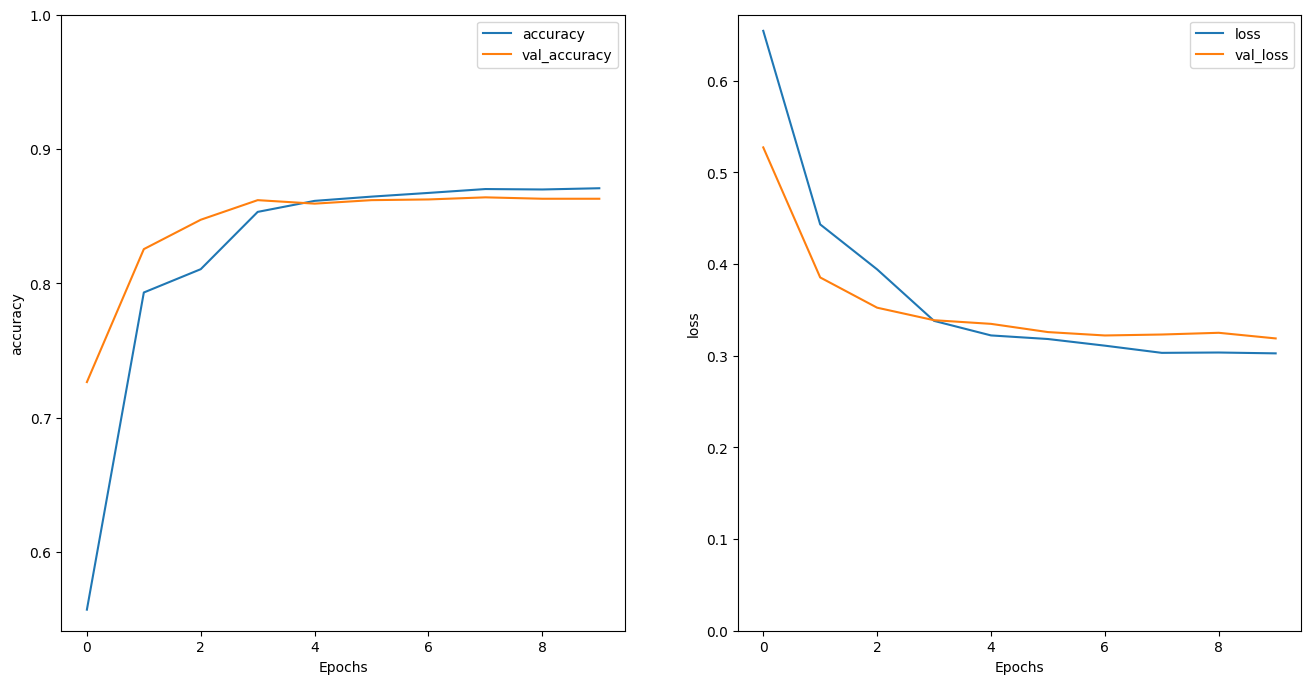

In [29]:
#SMALLER BUFFER (100)
BUFFER_SIZE = 100
BATCH_SIZE = 64
VOCAB_SIZE = 1000

train_ds_small_buf = (dataset['train']
                      .shuffle(BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      .prefetch(tf.data.AUTOTUNE))
test_ds_small_buf = (dataset['test']
                      .batch(BATCH_SIZE)
                      .prefetch(tf.data.AUTOTUNE))

encoder_sb = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder_sb.adapt(train_ds_small_buf.map(lambda text, label: text))

model_sb = tf.keras.Sequential([
    encoder_sb,
    tf.keras.layers.Embedding(len(encoder_sb.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_sb.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                 optimizer=tf.keras.optimizers.Adam(1e-4),
                 metrics=['accuracy'])

history_sb = model_sb.fit(train_ds_small_buf, epochs=10,
                           validation_data=test_ds_small_buf,
                           validation_steps=30)

loss_sb, acc_sb = model_sb.evaluate(test_ds_small_buf)
print(f'Small buffer (100) - Test accuracy: {acc_sb:.4f}')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history_sb, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_sb, 'loss')
plt.ylim(0, None)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5675 - loss: 0.6344 - val_accuracy: 0.7734 - val_loss: 0.4864
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.7736 - loss: 0.4606 - val_accuracy: 0.8318 - val_loss: 0.4195
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.8355 - loss: 0.3693 - val_accuracy: 0.8318 - val_loss: 0.3605
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.8549 - loss: 0.3376 - val_accuracy: 0.8380 - val_loss: 0.3436
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.8597 - loss: 0.3249 - val_accuracy: 0.8604 - val_loss: 0.3579
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.8618 - loss: 0.3188 - val_accuracy: 0.8604 - val_loss: 0.3286
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.8670 - loss: 0.3114 - val_accuracy: 0.8547 - val_loss: 0.3259
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.8688 - loss: 0.3070 - 

(0.0, 0.6511052057147027)

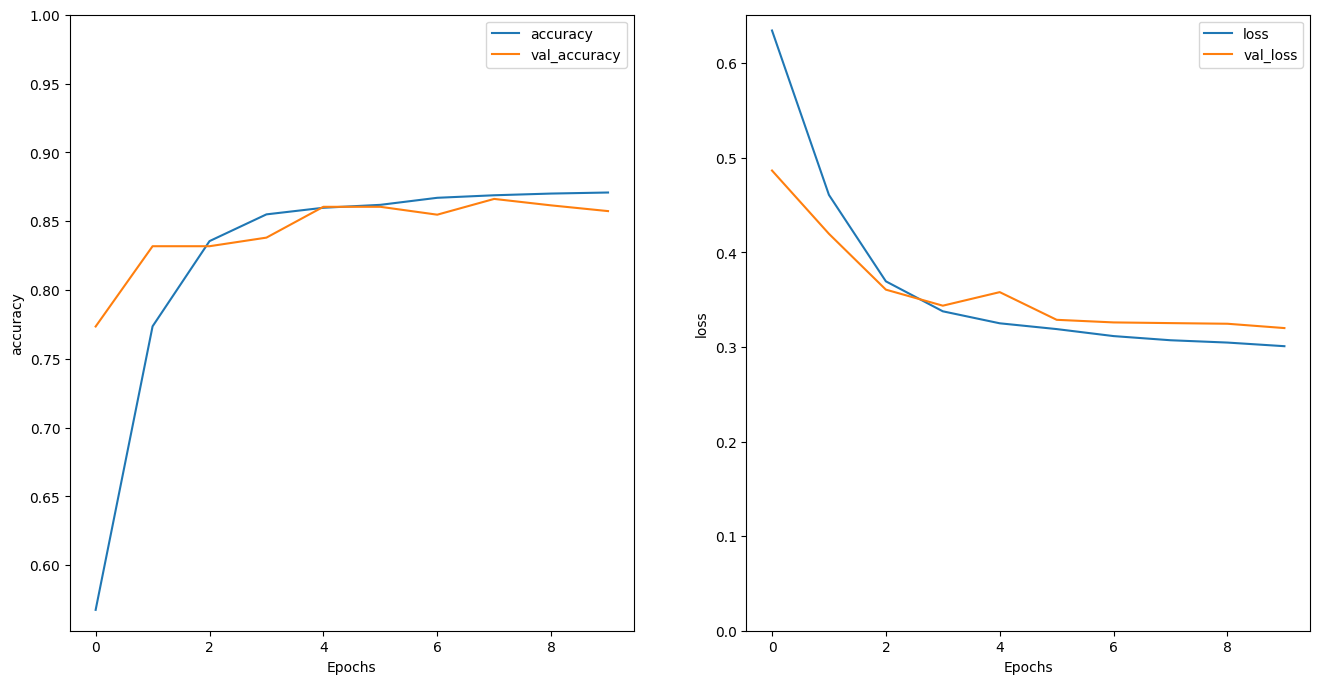

In [31]:
#BIGGER BUFFER (25K)
BUFFER_SIZE = 25000
BATCH_SIZE = 64
VOCAB_SIZE = 1000

train_ds_large_buf = (dataset['train']
                      .shuffle(BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      .prefetch(tf.data.AUTOTUNE))
test_ds_large_buf = (dataset['test']
                      .batch(BATCH_SIZE)
                      .prefetch(tf.data.AUTOTUNE))

encoder_lb = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder_lb.adapt(train_ds_large_buf.map(lambda text, label: text))

model_lb = tf.keras.Sequential([
    encoder_lb,
    tf.keras.layers.Embedding(len(encoder_lb.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_lb.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                 optimizer=tf.keras.optimizers.Adam(1e-4),
                 metrics=['accuracy'])

history_lb = model_lb.fit(train_ds_large_buf, epochs=10,
                           validation_data=test_ds_large_buf,
                           validation_steps=30)

loss_lb, acc_lb = model_lb.evaluate(test_ds_large_buf)
print(f'Large buffer (25000) - Test accuracy: {acc_lb:.4f}')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history_lb, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_lb, 'loss')
plt.ylim(0, None)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.5036 - loss: 0.6898 - val_accuracy: 0.4917 - val_loss: 0.6807
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.6184 - loss: 0.6011 - val_accuracy: 0.6979 - val_loss: 0.5452
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.7308 - loss: 0.5190 - val_accuracy: 0.7271 - val_loss: 0.5198
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.7532 - loss: 0.4960 - val_accuracy: 0.7422 - val_loss: 0.5017
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.7550 - loss: 0.4895 - val_accuracy: 0.7620 - val_loss: 0.5147
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.7583 - loss: 0.4867 - val_accuracy: 0.7474 - val_loss: 0.4950
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.7573 - loss: 0.4877 - val_accuracy: 0.7458 - val_loss: 0.4945
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.7582 - loss: 0.4856 -

(0.0, 0.7002172663807869)

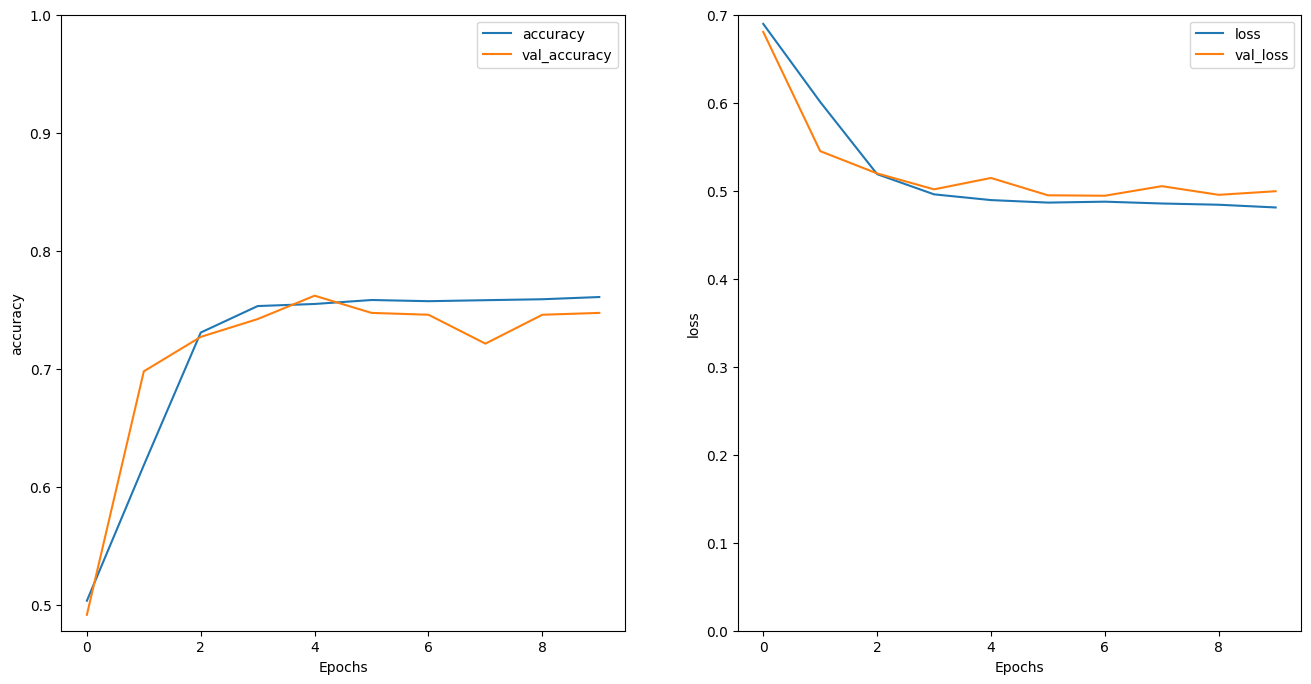

In [32]:
#SMALLER VOCAB (200)
BUFFER_SIZE = 10000
BATCH_SIZE = 64
VOCAB_SIZE = 200

train_ds_small_vocab = (dataset['train']
                  .shuffle(BUFFER_SIZE)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))
test_ds_small_vocab = (dataset['test']
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

encoder_sv = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder_sv.adapt(train_ds_small_vocab.map(lambda text, label: text))

model_sv = tf.keras.Sequential([
    encoder_sv,
    tf.keras.layers.Embedding(len(encoder_sv.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_sv.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer=tf.keras.optimizers.Adam(1e-4),
                metrics=['accuracy'])

history_sv = model_sv.fit(train_ds_small_vocab, epochs=10,
                         validation_data=test_ds_small_vocab,
                         validation_steps=30)

loss_sv, acc_sv = model_sv.evaluate(test_ds_small_vocab)
print(f'Small vocab (200) - Test accuracy: {acc_sv:.4f}')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history_sv, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_sv, 'loss')
plt.ylim(0, None)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.5838 - loss: 0.6246 - val_accuracy: 0.7786 - val_loss: 0.4437
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.8492 - loss: 0.3460 - val_accuracy: 0.8677 - val_loss: 0.3225
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.8940 - loss: 0.2572 - val_accuracy: 0.8557 - val_loss: 0.3076
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9084 - loss: 0.2270 - val_accuracy: 0.8391 - val_loss: 0.3477
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9190 - loss: 0.2040 - val_accuracy: 0.8760 - val_loss: 0.3047
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.9240 - loss: 0.1931 - val_accuracy: 0.8687 - val_loss: 0.3104
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9290 - loss: 0.1795 - val_accuracy: 0.8557 - val_loss: 0.3326
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9318 - loss: 0.1706 - 

(0.0, 0.6480103425681591)

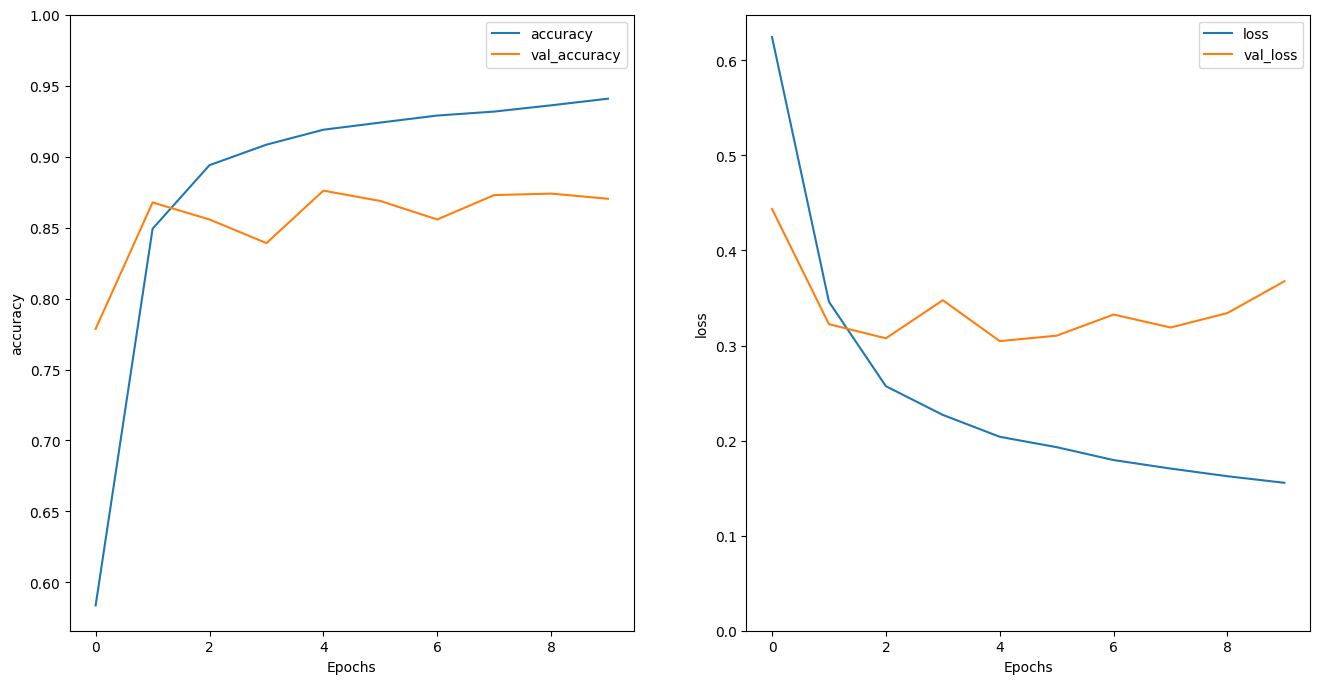

In [33]:
#BIGGER VOCAB (5000)
BUFFER_SIZE = 10000
BATCH_SIZE = 64
VOCAB_SIZE = 5000

train_ds_large_vocab = (dataset['train']
                  .shuffle(BUFFER_SIZE)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))
test_ds_large_vocab = (dataset['test']
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

encoder_lv = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder_lv.adapt(train_ds_large_vocab.map(lambda text, label: text))

model_lv = tf.keras.Sequential([
    encoder_lv,
    tf.keras.layers.Embedding(len(encoder_lv.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_lv.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer=tf.keras.optimizers.Adam(1e-4),
                metrics=['accuracy'])

history_lv = model_lv.fit(train_ds_large_vocab, epochs=10,
                         validation_data=test_ds_large_vocab,
                         validation_steps=30)

loss_lv, acc_lv = model_lv.evaluate(test_ds_large_vocab)
print(f'Large vocab (5000) - Test accuracy: {acc_lv:.4f}')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history_lv, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_lv, 'loss')
plt.ylim(0, None)

In [36]:
print(f'Baseline  (buffer=10000,  vocab=1000):  {acc_base:.4f}')
print(f'Small buf (buffer=100,    vocab=1000):  {acc_sb:.4f}')
print(f'Large buf (buffer=25000,  vocab=1000):  {acc_lb:.4f}')
print(f'Small voc (buffer=10000,  vocab=200):   {acc_sv:.4f}')
print(f'Large voc (buffer=10000,  vocab=5000):  {acc_lv:.4f}')

Baseline  (buffer=10000,  vocab=1000):  0.8577
Small buf (buffer=100,    vocab=1000):  0.8617
Large buf (buffer=25000,  vocab=1000):  0.8603
Small voc (buffer=10000,  vocab=200):   0.7547
Large voc (buffer=10000,  vocab=5000):  0.8706


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.4917 - val_loss: 0.6921
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.5001 - loss: 0.6839 - val_accuracy: 0.4922 - val_loss: 0.6822
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 634s 2s/step - accuracy: 0.6924 - loss: 0.5394 - val_accuracy: 0.8182 - val_loss: 0.4464
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 619s 2s/step - accuracy: 0.8315 - loss: 0.3863 - val_accuracy: 0.8359 - val_loss: 0.3782
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.8482 - loss: 0.3513 - val_accuracy: 0.8464 - val_loss: 0.3840
391/391 ━━━━━━━━━━━━━━━━━━━━ 165s 422ms/step - accuracy: 0.8502 - loss: 0.3701
SimpleRNN - Test accuracy: 0.8502


(0.0, 0.7095714494585991)

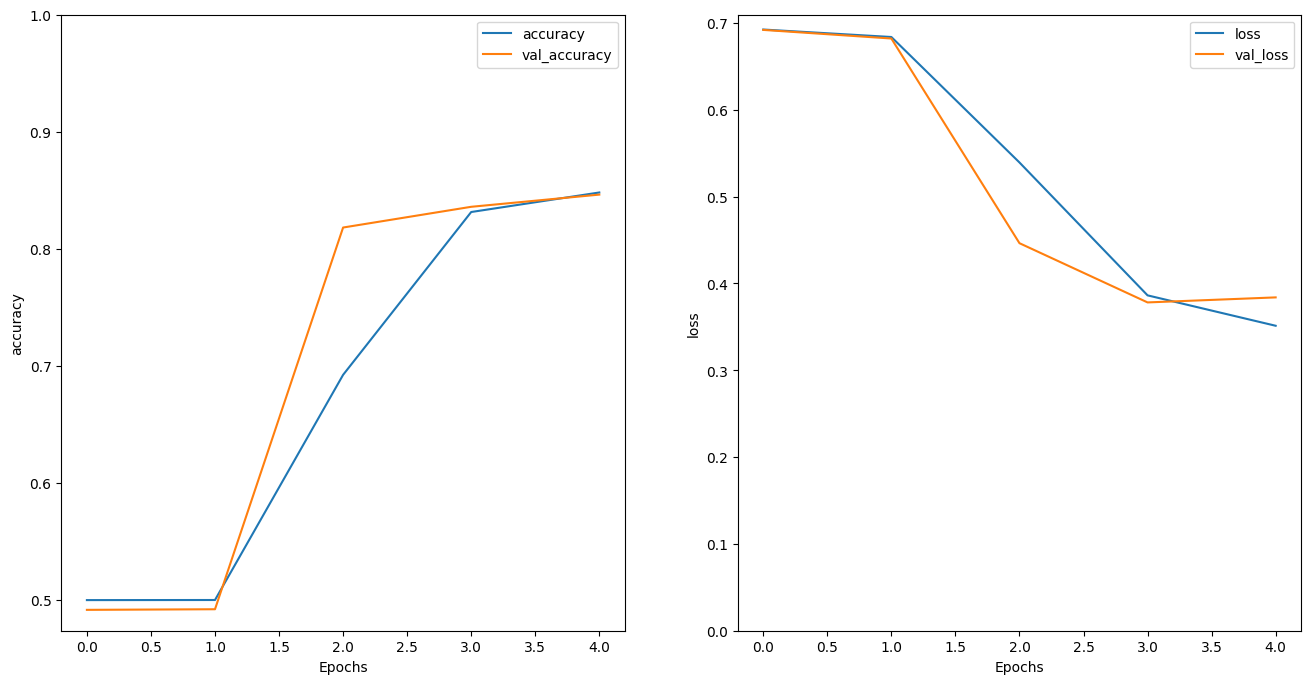

In [37]:
#COMPARING BIDRECTIONAL LSTM, SIMPLERNN

from keras.layers import SimpleRNN

BUFFER_SIZE = 10000
BATCH_SIZE = 64
VOCAB_SIZE = 1000

train_ds_rnn = (dataset['train']
                .shuffle(BUFFER_SIZE)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))
test_ds_rnn = (dataset['test']
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))
encoder_rnn = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder_rnn.adapt(train_ds_rnn.map(lambda text, label: text))

model_rnn = tf.keras.Sequential([
    encoder_rnn,
    tf.keras.layers.Embedding(len(encoder_rnn.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model_rnn.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer=tf.keras.optimizers.Adam(1e-4),
                  metrics=['accuracy'])

history_rnn = model_rnn.fit(train_ds_rnn, epochs=5,
                             validation_data=test_ds_rnn,
                             validation_steps=30)

loss_rnn, acc_rnn = model_rnn.evaluate(test_ds_rnn)
print(f'SimpleRNN - Test accuracy: {acc_rnn:.4f}')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history_rnn, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_rnn, 'loss')
plt.ylim(0, None)